The notebook is divided in these parts:
## 1.   *Importing Libraries*
## 2.   *Importing Dataset*
## 3.   *Preprocessing*
## 4.   *Feature Engineering*
## 5.   *Model Training*
## 6.   *Evaluation and Prediction*
## 7.   *Deployment*
---

# 📔 Project Notebook Structure
```bibtex
1. Tasks are distributed across teams and organized by notebook titles
   Each notebook documents:
    - Code implementation for task completion
    - Relevant comments and annotations

2. Agile Project Methodology:
    Weekly iterations training 1-2 models

    Project completion criteria:
        Best performing model achieves target evaluation metrics

3. The Pipeline of notebook:
   a. Doing EDA on dataset and finding information about that
   
   b. Applying preprocessing on dataset by information:
      i.   Class balancing
      ii.  Data augmentation
      iii. Normalization
      iv.  De-noising

   c. Feature extraction:
      i. Using some trained model
      ii. Extracting using Deep Learning (MFCC, MEL spectograms)

   d. Model training:
      i. Using trained model and fine tune that
      ii. Implement from scratch with torch, keras

   e. Evaluation with accuracy, precision, recall, f1-score (Confusion Matrix)
```

💡 Tips:
``` python
  1. For unfinished section use this: #TODO
  2. The structure of task like this:
      # [TASK NAME] (Assignee: @username)
      # Sprint Goal: [e.g., "Improve Wav2Vec2 accuracy by 5%"]
      # Deadline: DD/MM  
```


# 1. *Libraries*



**Installing**



In [3]:
!pip install numpy==2.0.0 -q

In [4]:
!pip install noisereduce openai-whisper datasets evaluate jiwer -q -U

**Importing**

In [5]:
# For Data Processing
import numpy as np
import pandas as pd
import os
import shutil
import random
import json
import datetime
import zipfile
import kagglehub
from sklearn.utils import shuffle
from tqdm import tqdm
from pathlib import Path
from evaluate import load
from sklearn.utils import resample

#  For Plotting
import matplotlib.pyplot as plt
import seaborn as sns


# For Speech Processing
import torchaudio
import librosa
import scipy.signal as signal
import IPython.display as ipd
import soundfile as sf
import noisereduce as nr
import torchaudio.transforms as T

# For DL, Classifier,... Model (Sklearn, pytorch, keras, Tensorflow,...)
import tensorflow_hub as hub
import whisper
import torch
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2ForCTC
from sklearn.model_selection import train_test_split

# For object oriented in python
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Tuple, List, Optional, Union
from collections import defaultdict

# If you need other libraries to be imported write it here


# *2. Dataset - EDA*

**`DONE`**\
Importing Dataset - (Assignee: Sepehr)\
Sprint Goal: [Importing Dataset from kaggle and making a folder in colab]\
Deadline: 02/May

In [4]:
# Importing Dataset From Kaggle
path = kagglehub.dataset_download("sepehrsimkhah/speech-dataset-pazhvak")

print("Path to dataset files:", path)

100%|██████████| 3.77G/3.77G [00:40<00:00, 100MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sepehrsimkhah/speech-dataset-pazhvak/versions/1


In [5]:
# Validating Dataset Path
list_of_dataset = os.listdir(path)
list_of_dataset

['1201-1600',
 '2001-2400',
 'P1993818924117826_1247741184149835.xlsx',
 '2801-3200',
 '3601-4018',
 '1-400',
 '801-1200',
 '3201-3600',
 '401-800',
 '1601-2000',
 '2401-2800']

In [6]:
word_table = os.path.join(path, 'P1993818924117826_1247741184149835.xlsx')
df = pd.read_excel(word_table)
df.sample(5)

,Folder Number,Persian Word
2375,2376,می شناسی
2731,2732,دراچین
2374,2375,می شناسم
3816,3817,ماشین
2411,2412,می‌خوانی


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Folder Number  4018 non-null   int64 
 1   Persian Word   4017 non-null   object
dtypes: int64(1), object(1)
memory usage: 62.9+ KB


In [8]:
df.isna()

,Folder Number,Persian Word
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
4013,False,False
4014,False,False
4015,False,False
4016,False,False


**`DONE`**\
TODO: Fixing the voice problem (assignee: Sepehr)

In [9]:
# by doing this we found out that we have a nan value
df_false = df[df.isna().any(axis=1)]
df_false

,Folder Number,Persian Word
662,663,NaN


i listend the voices of folder 663th and i found out that the 663 is "کارفرما"

In [ ]:
row = df[df["Persian Word"] == "کارفرما"]
row

,Folder Number,Persian Word
3778,3779,کارفرما


this word has two folders, I Don't know why but:\
a folder is "کارفرما" with men voices (3779)\
the other one is "کارفرما" with women voices (663)

In [ ]:
# it's 10 folders
list_of_folders = list_of_dataset.copy()
list_of_folders.remove('P1993818924117826_1247741184149835.xlsx')
list_of_folders

['2801-3200',
 '1-400',
 '3601-4018',
 '2001-2400',
 '401-800',
 '1601-2000',
 '3201-3600',
 '1201-1600',
 '801-1200',
 '2401-2800']

این شخص کلمه "شستن" رو خیلی باحال گفته به همین خاطر رانش نکنید

In [ ]:
# finding the audio of word by number folder

def find_word_range(folder_number:int, folders:list):
  for word_range in folders:
    start_word_range, stop_word_range = word_range.split("-")
    if int(start_word_range) <= folder_number <= int(stop_word_range):
      return start_word_range, stop_word_range, word_range

random_number_folder = random.randint(0, 4018)
word = (df[df["Folder Number"] == random_number_folder])["Persian Word"].values[0]
_, _, word_range = find_word_range(random_number_folder, list_of_folders)
path_example = os.path.join(f"{path}/{word_range}/{random_number_folder}/")
list_audio_example = os.listdir(path_example)
audio_file = path_example + list_audio_example[random.randint(0, len(list_audio_example)-1)]

print(f"Word: {word}")
print("Loading:", audio_file)
assert os.path.exists(audio_file), f"File {audio_file} not found!"

y, sr = librosa.load(audio_file, sr=None)
print(sr)
ipd.Audio(y, rate=sr)



Word: 204    شستن
Name: Persian Word, dtype: object
Loading: /kaggle/input/speech-dataset-pazhvak/1-400/205/FA_16000_0013.wav
16000


In [ ]:
# Some Examples

def play_audio_samples(path:str, word_table:pd.DataFrame, folders:list, num_samples:int=2):
    for _ in range(num_samples):
        random_number_folder = random.randint(0, len(word_table) - 1)

        word_row = word_table[word_table["Folder Number"] == random_number_folder]
        if word_row.empty:
            continue

        word = word_row["Persian Word"].values[0]
        start_range, end_range, word_range = find_word_range(random_number_folder, folders)

        folder_path = os.path.join(path, word_range, str(random_number_folder))
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        audio_files = os.listdir(folder_path)
        if not audio_files:
            print(f"No audio files in: {folder_path}")
            continue

        audio_file = os.path.join(folder_path, random.choice(audio_files))

        print(f"\nWord: {word} (Folder: {random_number_folder})")
        print(f"Audio file: {audio_file}")

        try:
            y, sr = librosa.load(audio_file, sr=None)
            display(ipd.Audio(y, rate=sr))
        except Exception as e:
            print(f"Error loading audio: {e}")

In [ ]:
play_audio_samples(path=path,word_table=df,folders=list_of_folders,num_samples=3)


Word: شنید  (Folder: 120)
Audio file: /kaggle/input/speech-dataset-pazhvak/1-400/120/FA_16000_0008.wav



Word: سوراخ (Folder: 591)
Audio file: /kaggle/input/speech-dataset-pazhvak/401-800/591/FA_16000_0021.wav



Word: زمین شناس (Folder: 3915)
Audio file: /kaggle/input/speech-dataset-pazhvak/3601-4018/3915/FA_16000_0015.wav


**`DONE`**\
EDA On Dataset - (Assignee: Sepehr)\
Sprint Goal: [Using some functions to analyzing voices and getting some informations]\
Deadline: 02/May

In [7]:
class IAudioAnalyzer(ABC):
    @abstractmethod
    def analyze(self, signal: np.ndarray, sample_rate: int) -> dict:
        pass

    @abstractmethod
    def plot(self, signal: np.ndarray, sample_rate: int):
        pass

#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Audio Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

@dataclass
class AudioSample:
    signal: np.ndarray
    sample_rate: int
    metadata: dict = None

class AudioAnalyzer:
    def __init__(self, audio_sample: AudioSample):
        self.audio = audio_sample

    def raw_waveform_plot(self):
        plt.figure(figsize=(12, 4))
        librosa.display.waveshow(y=self.audio.signal, sr=self.audio.sample_rate)
        plt.title("Raw Waveform")
        plt.show()

    def fft_spectrum_plot(self):
        fft = np.fft.fft(self.audio.signal)
        freq = np.fft.fftfreq(len(self.audio.signal), 1/self.audio.sample_rate)
        plt.figure(figsize=(12, 4))
        plt.plot(freq[:len(freq)//2], np.abs(fft)[:len(freq)//2])
        plt.title("FFT Spectrum")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.show()

    def stft_spectrogram_plot(self, scale: str = "log"):
        D = librosa.stft(self.audio.signal, n_fft=2048, hop_length=512)
        s_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(s_db, sr=self.audio.sample_rate,
                                hop_length=512, x_axis='time', y_axis=scale)
        plt.colorbar(format='%+2.0f dB')
        plt.title("STFT Spectrogram")
        plt.show()

    def mel_spectrogram_plot(self, n_mels: int = 80):
        S = librosa.feature.melspectrogram(y=self.audio.signal, sr=self.audio.sample_rate, n_mels=n_mels)
        S_db = librosa.power_to_db(S, ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(S_db, sr=self.audio.sample_rate, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title("Mel Spectrogram")
        plt.show()
        return S_db

    def mfcc_plot(self, n_mfcc: int = 13):
        mfccs = librosa.feature.mfcc(y=self.audio.signal, sr=self.audio.sample_rate, n_mfcc=n_mfcc)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(mfccs, sr=self.audio.sample_rate, x_axis='time')
        plt.colorbar()
        plt.title("MFCC Features")
        plt.show()


In [8]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<<Word Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class WordAnalyzer:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def word_count(self) -> pd.DataFrame:
        word_stats = []

        for word, group in self.dataset.metadata.groupby('Persian Word'):
            voice_count = 0
            folder_count = len(group)

            for _, row in group.iterrows():
                folder_num = row['Folder Number']
                word_range = self.dataset._find_word_range(folder_num)
                folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

                if os.path.exists(folder_path):
                    voice_count += len([f for f in os.listdir(folder_path)
                                     if f.endswith(('.wav', '.mp3', '.flac'))])

            word_stats.append({
                'Persian Word': word,
                'Voice Count': voice_count,
                'Folder Count': folder_count
            })

        return pd.DataFrame(word_stats)

    def most_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count', ascending=False).head(top_n)

    def least_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count').head(top_n)

    def plot_voice_distribution(self):
        word_stats = self.word_count()
        voice_counts = word_stats['Voice Count'].value_counts().sort_index()

        plt.figure(figsize=(12, 6))
        voice_counts.plot(kind='bar')
        plt.title("Distribution of Voice Counts per Word")
        plt.xlabel("Number of Voices")
        plt.ylabel("Number of Words")
        plt.grid(True)
        plt.show()

In [9]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Dataset Statistics>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class DatasetStatistics:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def analyze_durations(self) -> dict:
        durations = []
        total_files = 0

        for _, row in tqdm(self.dataset.metadata.iterrows(), total=len(self.dataset.metadata), desc="Analyzing durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                total_files += len(audio_files)

                for file in audio_files:
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        if not durations:
            return {}

        avg_dur = sum(durations)/len(durations)
        max_dur = max(durations)
        min_dur = min(durations)

        above_avg = sum(1 for d in durations if d > avg_dur)
        below_avg = len(durations) - above_avg

        return {
            'avg': avg_dur,
            'max': max_dur,
            'min': min_dur,
            'above_avg': above_avg,
            'below_avg': below_avg,
            'total_files': total_files
        }

    def plot_duration_distribution(self, sample_size: int = 500):
        durations = []
        sampled_metadata = self.dataset.metadata.sample(min(sample_size, len(self.dataset.metadata)))

        for _, row in tqdm(sampled_metadata.iterrows(), total=len(sampled_metadata), desc="Sampling durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                for file in audio_files[:2]:  # Max 2 files per folder
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        plt.figure(figsize=(12, 6))
        plt.hist(durations, bins=50, edgecolor='black')
        plt.title("Distribution of Audio Durations")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Number of Voices")
        plt.grid(True)
        plt.show()

In [10]:
# class to return dataset information

class PazhvakDataset:
    """A class to handle Persian audio dataset with metadata and folder structure."""

    def __init__(self, dataset_path: str, metadata_file: str):
        """
        Args:
            dataset_path (str): Root path of the dataset
            metadata_file (str): Path to metadata file (Excel/CSV) relative to dataset_path
        """
        self.dataset_path = dataset_path
        self.metadata_path = os.path.join(dataset_path, metadata_file)

        # Load metadata
        self.metadata = self._load_metadata()
        self.word_range_folders = self._extract_word_ranges(metadata_file)

        self.audio_analyzer = AudioAnalyzer
        self.word_analyzer = WordAnalyzer(self)
        self.stats = DatasetStatistics(self)

        # Initialize splits
        self.train_indices: list = []
        self.val_indices: list = []
        self.test_indices: list = []

    def _load_metadata(self) -> pd.DataFrame:
        """Load metadata file (supports .csv, .xlsx)"""
        if self.metadata_path.endswith('.csv'):
            return pd.read_csv(self.metadata_path)

        elif self.metadata_path.endswith('.xlsx'):
            return pd.read_excel(self.metadata_path)

        else:
            raise ValueError("Unsupported file format. Use .csv or .xlsx")

    def _extract_word_ranges(self, metadata_file: str) -> list:
        """Extract folder ranges from dataset path"""
        list_of_folders = os.listdir(self.dataset_path)
        list_of_folders.remove(metadata_file)
        return list_of_folders

    def __len__(self) -> int:
        """Returns total number of audio folders"""
        return len(self.word_range_folders)

    def get_audio_sample(self, index: int = None, num_samples: int = 1) -> list:
        """
        Get audio sample(s) by index or random

        Args:
            index (int): Specific index to get (None for random)
            num_samples (int): Number of samples to return (default: 1)

        Returns:
            list: List of tuples (audio_data, sample_rate, word, metadata_row)
        """
        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        samples = []

        for _ in range(num_samples):
            current_index = index if index is not None else random.randint(0, len(self.metadata)-1)

            try:
                row = self.metadata.iloc[current_index]
                folder_num = row['Folder Number']
                word_range = self._find_word_range(folder_num)

                audio_folder = os.path.join(
                    self.dataset_path,
                    word_range,
                    str(folder_num))

                if not os.path.exists(audio_folder):
                    continue

                audio_files = [f for f in os.listdir(audio_folder) if f.endswith(('.wav', '.mp3', '.flac'))]
                if not audio_files:
                    continue

                audio_file = os.path.join(audio_folder, random.choice(audio_files))
                y, sr = librosa.load(audio_file, sr=None)

                samples.append((y, sr, row['Persian Word'], row))
            except Exception as e:
                print(f"Error loading sample {current_index}: {str(e)}")
                continue

        return samples

    def _find_word_range(self, folder_number: int) -> str:
        """Find which range folder the number belongs to"""
        for word_range in self.word_range_folders:
            start, end = map(int, word_range.split('-'))
            if start <= folder_number <= end:
                return word_range
        raise ValueError(f"Folder number {folder_number} out of range")

    def split_dataset(self, test_size: float = 0.2, val_size: float = 0.1,
                     random_state: int = 42) -> None:
        """
        Split dataset into train/val/test sets

        Args:
            test_size (float): Proportion for test set
            val_size (float): Proportion for validation set
            random_state (int): Random seed for reproducibility
        """
        train_val_idx, test_idx = train_test_split(
            range(len(self.metadata)),
            test_size=test_size,
            random_state=random_state
        )

        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=val_size/(1-test_size),
            random_state=random_state
        )

        self.train_indices = train_idx
        self.val_indices = val_idx
        self.test_indices = test_idx

    def play_random_sample(self, split: str = None, num_samples: int = 1) -> None:
        """
        Play random audio samples from specified split

        Args:
            split (str): One of 'train', 'val', 'test', or None for entire dataset
            num_samples (int): Number of samples to play (default: 1)
        """
        if split not in [None, 'train', 'val', 'test']:
            raise ValueError("split must be one of: None, 'train', 'val', 'test'")

        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        if split and not getattr(self, f"{split}_indices"):
            raise ValueError(f"{split} split not initialized. Call split_dataset() first")

        for i in range(num_samples):
            index = None
            if split == 'train':
                index = random.choice(self.train_indices)
            elif split == 'val':
                index = random.choice(self.val_indices)
            elif split == 'test':
                index = random.choice(self.test_indices)
            else:
                index = random.randint(0, len(self.metadata)-1)

            try:
                y, sr, word, metadata = self.get_audio_sample(index)[0]  # Get first (and only) sample
                print(f"\nSample #{i+1}/{num_samples}")
                print(f"Word: {word}")
                print(f"Folder: {metadata['Folder Number']}")
                print(f"Audio length: {len(y)/sr:.2f} seconds")
                display(ipd.Audio(y, rate=sr))
            except Exception as e:
                print(f"Error playing sample: {str(e)}")
                continue

In [ ]:
dataset = PazhvakDataset(dataset_path=path,metadata_file='P1993818924117826_1247741184149835.xlsx')

In [ ]:
# Split dataset
dataset.split_dataset(test_size=0.2, val_size=0.1)

In [13]:
# testing
single_sample = dataset.get_audio_sample(index=42)
four_samples = dataset.get_audio_sample(num_samples=4)
dataset.play_random_sample()
single_sample


Sample #1/1
Word: دماغ
Folder: 3387
Audio length: 2.66 seconds


[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'پشت',
  Folder Number     43
  Persian Word     پشت
  Name: 42, dtype: object)]

In [15]:
four_samples

[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'شنیده ای',
  Folder Number        1408
  Persian Word     شنیده ای
  Name: 1407, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'نابغه',
  Folder Number      771
  Persian Word     نابغه
  Name: 770, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'جغد',
  Folder Number    1000
  Persian Word      جغد
  Name: 999, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'نوشته',
  Folder Number     1351
  Persian Word     نوشته
  Name: 1350, dtype: object)]

In [14]:
dataset.play_random_sample(num_samples=3)


Sample #1/3
Word: کوبیده اید
Folder: 1578
Audio length: 3.45 seconds



Sample #2/3
Word: دسته بندی
Folder: 175
Audio length: 3.22 seconds



Sample #3/3
Word: سوخاری
Folder: 3708
Audio length: 3.31 seconds


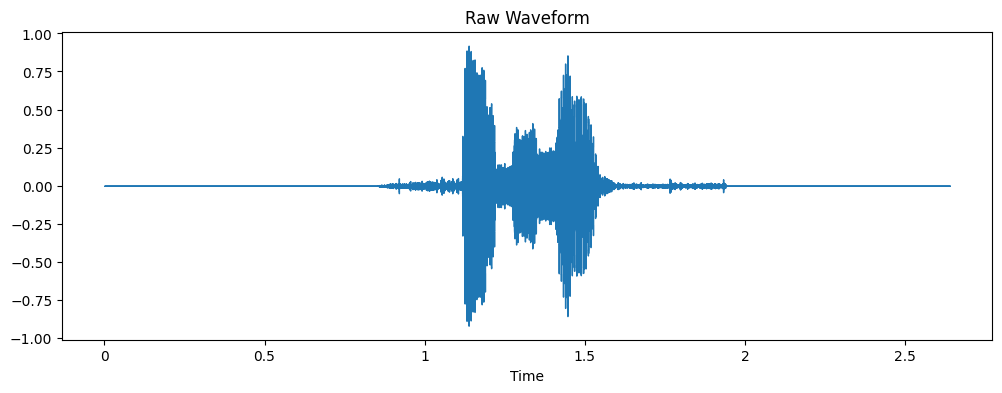

In [28]:
# Audio Analysis Test

# Load a sample
y, sr, word, metadata = dataset.get_audio_sample()[0]
audio_sample = AudioSample(y, sr, metadata)

# Audio analysis
audio_analyzer = AudioAnalyzer(audio_sample)
audio_analyzer.raw_waveform_plot()



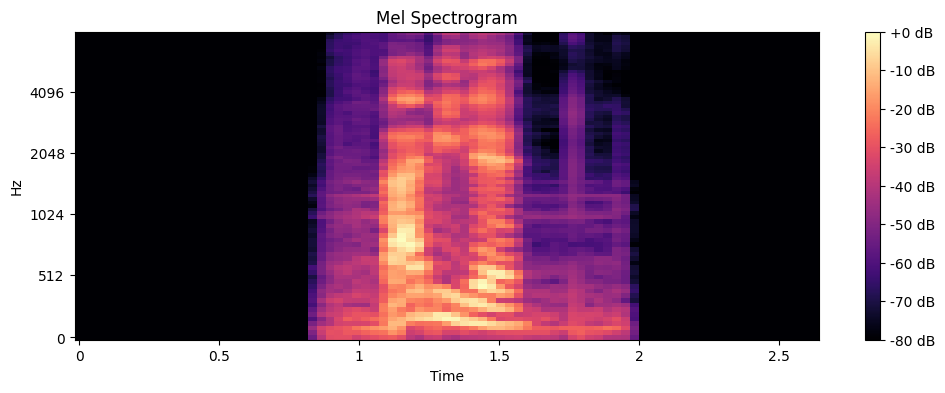

In [29]:
audio_analyzer.mel_spectrogram_plot()
plt.show()

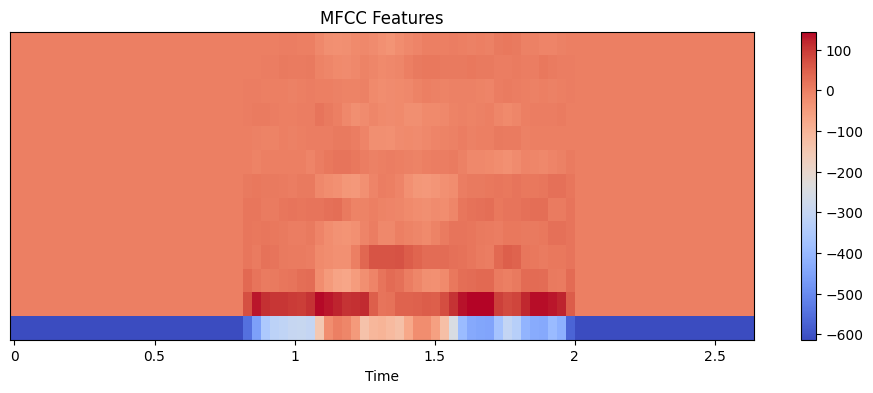

In [30]:
audio_analyzer.mfcc_plot()

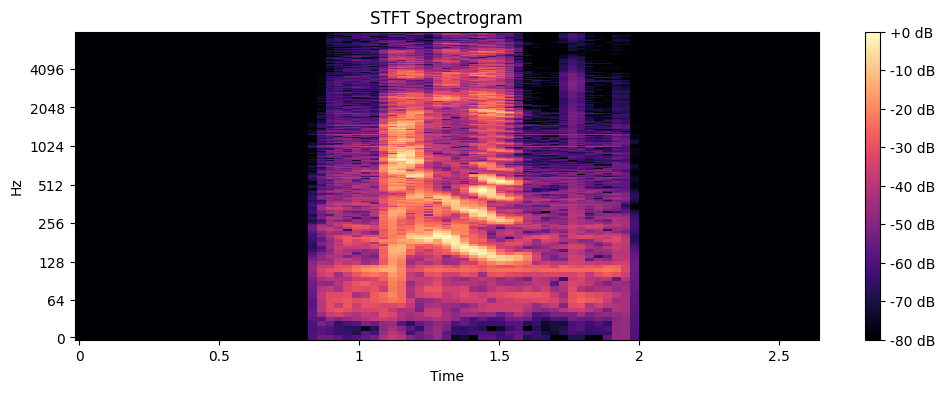

In [31]:
audio_analyzer.stft_spectrogram_plot()

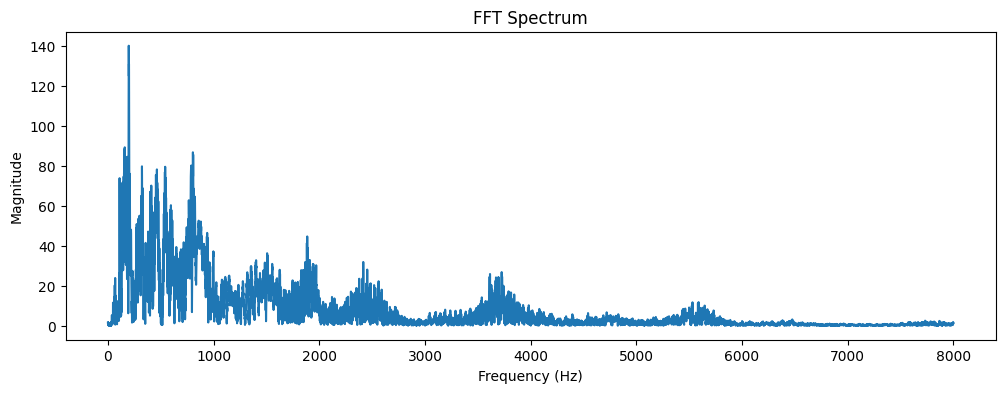

In [32]:
audio_analyzer.fft_spectrum_plot()

In [33]:
ipd.Audio(y, rate=sr)

In [34]:
# Word analysis Test
word_stats = dataset.word_analyzer.word_count()
word_stats

,Persian Word,Voice Count,Folder Count
0,می گوید,14,1
1,آب,50,2
2,آب دوغ,21,1
3,آب شش,38,2
4,آب مروارید,18,1
...,...,...,...
3637,یرسند,18,1
3638,یلدا,20,1
3639,یوزپلنگ,20,1
3640,یکسان,30,1


In [35]:
top_words = dataset.word_analyzer.most_common_words(10)
top_words

,Persian Word,Voice Count,Folder Count
1300,رسید,82,4
1550,سلام,80,3
1120,دسر,76,3
1595,سگ,70,3
1899,عجله,70,3
3082,هیچ,70,3
3053,هدف,70,3
2072,قاب,68,3
2112,قلب,68,3
5,آب نما,68,3


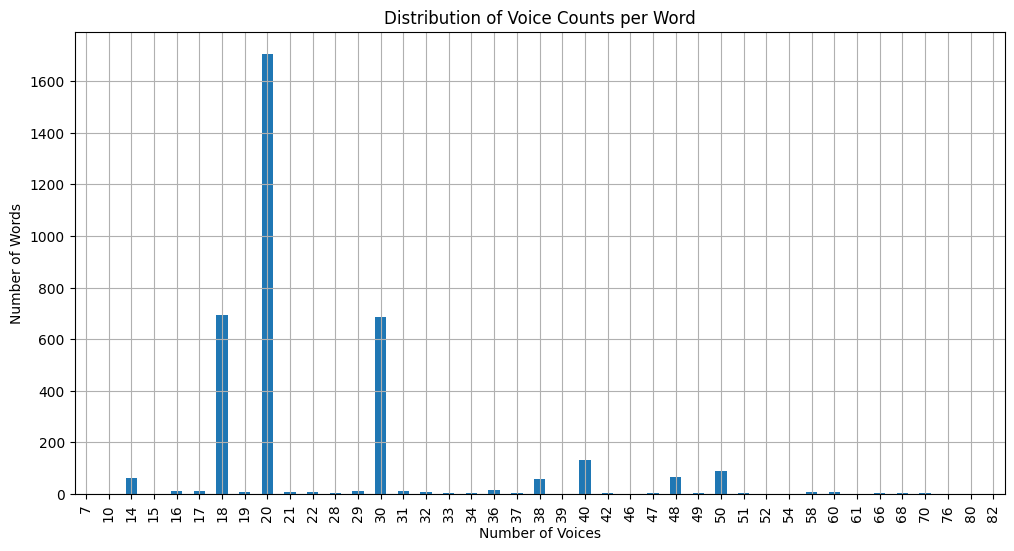

In [36]:
dataset.word_analyzer.plot_voice_distribution()

In [37]:
# Dataset statistics Test
duration_stats = dataset.stats.analyze_durations()
duration_stats

Analyzing durations: 100%|██████████| 4018/4018 [02:03<00:00, 32.49it/s]


{'avg': 3.1220696091084514,
 'max': 8.9836875,
 'min': 1.3166875,
 'above_avg': 38685,
 'below_avg': 49837,
 'total_files': 88522}

Sampling durations: 100%|██████████| 500/500 [00:01<00:00, 308.94it/s]


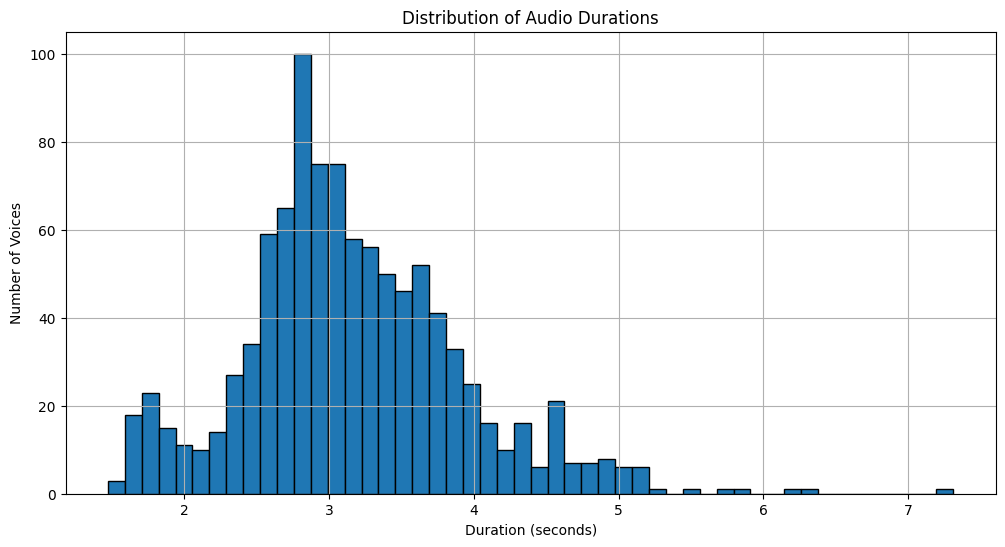

In [38]:
dataset.stats.plot_duration_distribution()

Exploratory Data Analysis

📝 **RESULT:**



> Dataset Information: It's not good, the distribution and mis-place of voices in a folder is too much (the word is "سیب" but the voice is "پرتقال"). some of voices are not good. Dataset has good denoising and it really don't need any preprocessing but we can just use **Trim Silence, padding or trimmming, loudness normalization, normalization** preprocessing, also don't need any


```
Dataset Problem:
  feature extraction just mfcc or mel-spectrograms.
  The duration distribution is acceptable and don't need anything.
  The voice count of some words are not good and should be fixed.
  Some voices has more than avg duration which is 3.122s(like 8s).
  Some folders or voices are tagged wrongly and should be fixed.
  Lack of having not much dataset for each word and using data augmentation techniques (Maybe creating artificial voices🙂 - need to be researched).

Requirements:
  Researching about what techniques are good for preprocessing and feature extraction.
  What techniques should we do for solving our problems.
```





# *3. Preprocessing*

In [15]:
# Writing prerprocessing function for dataset
class DatasetBalancer:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset
        self.metadata = self._clean_metadata(dataset.metadata)

    def _clean_metadata(self, metadata: pd.DataFrame) -> pd.DataFrame:
        return metadata.dropna(subset=['Folder Number', 'Persian Word'])

    def _collect_all_word_samples(self) -> dict:
        """Collect all audio files per Persian word from all folders."""
        word_samples = defaultdict(list)

        for _, row in self.metadata.iterrows():
            folder_num = int(row['Folder Number'])
            word = row['Persian Word']
            folder_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, folder_range, str(folder_num))
            if os.path.exists(folder_path):
                for f in os.listdir(folder_path):
                    if f.endswith(('.wav', '.mp3', '.flac')):
                        word_samples[word].append((folder_path, f))
        return word_samples

    def _augment_audio(self, y: np.ndarray, sr: int) -> np.ndarray:
        """Apply one of several audio augmentation techniques for up sampling."""
        choice = random.choice(['noise', 'pitch', 'stretch'])
        if choice == 'noise':
            noise = np.random.normal(0, 0.005, y.shape)
            return y + noise
        elif choice == 'pitch':
            return librosa.effects.pitch_shift(y, sr, n_steps=random.choice([-2, -1, 1, 2]))
        elif choice == 'stretch':
            rate = random.uniform(0.8, 1.2)
            y_stretched = librosa.effects.time_stretch(y, rate)
            return y_stretched[:len(y)]  # Trim/pad to original length
        return y

    def balance_dataset(self, output_dataset_path: str) -> pd.DataFrame:
        os.makedirs(output_dataset_path, exist_ok=True)
        word_samples = self._collect_all_word_samples()

        avg_count = int(np.mean([len(v) for v in word_samples.values()]))
        print("The average voice count is: ",avg_count)
        new_metadata = []

        folder_counter = 1

        for word, samples in tqdm(word_samples.items(), desc="Balancing dataset"):
            total_needed = avg_count

            if len(samples) >= total_needed:
                selected = random.sample(samples, total_needed)
            else:
                selected = samples.copy()
                while len(selected) < total_needed:
                    src_folder, src_file = random.choice(samples)
                    src_path = os.path.join(src_folder, src_file)
                    try:
                        y, sr = librosa.load(src_path, sr=None)
                        y_aug = self._augment_audio(y, sr)
                        aug_id = f"{folder_counter}_{len(selected) + 1}"
                        tmp_filename = f"tmp_aug_{aug_id}.wav"
                        tmp_path = os.path.join(output_dataset_path, tmp_filename)
                        sf.write(tmp_path, y_aug, sr)
                        selected.append((output_dataset_path, tmp_filename))

                    except:
                        continue

            # Assign new folder and copy files with new naming
            folder_range = self._find_new_folder_range(folder_counter)
            folder_path = os.path.join(output_dataset_path, folder_range, str(folder_counter))
            os.makedirs(folder_path, exist_ok=True)

            for idx, (src_folder, filename) in enumerate(selected):
                new_filename = f"FA_16000_{idx + 1:04d}.wav"
                dst_path = os.path.join(folder_path, new_filename)

                if filename.startswith("tmp_aug_"):  # handle augmented audio
                    shutil.move(os.path.join(src_folder, filename), dst_path)
                else:
                    src_path = os.path.join(src_folder, filename)
                    shutil.copy2(src_path, dst_path)

            new_metadata.append((folder_counter, word))
            folder_counter += 1

        # Save new label.xlsx
        label_df = pd.DataFrame(new_metadata, columns=["Folder Number", "Persian Word"])
        label_path = os.path.join(output_dataset_path, "P1993818924117826_1247741184149835.xlsx")
        label_df.to_excel(label_path, index=False)

        return label_df

    def _find_new_folder_range(self, folder_num: int) -> str:
        """Helper to generate folder range path like '1-400', '401-800', etc."""
        range_size = 400
        start = ((folder_num - 1) // range_size) * range_size + 1
        end = start + range_size - 1
        return f"{start}-{end}"


In [16]:
# Running dataset preprocessing
balanced_dataset_path = "/content/balanced_pazhvak"
balancer = DatasetBalancer(dataset)
balanced_metadata = balancer.balance_dataset(output_dataset_path=balanced_dataset_path)


The average voice count is:  24


Balancing dataset: 100%|██████████| 3642/3642 [03:57<00:00, 15.34it/s]


In [17]:
# changing dataset path of pazhvakdataset class
dataset = PazhvakDataset(dataset_path=balanced_dataset_path, metadata_file="P1993818924117826_1247741184149835.xlsx")

In [18]:
print(len(dataset.metadata))
# from 4018 to 3642

3642


In [19]:
dataset.metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Folder Number  3642 non-null   int64 
 1   Persian Word   3642 non-null   object
dtypes: int64(1), object(1)
memory usage: 57.0+ KB


In [20]:
# Word analysis Test
word_stats = dataset.word_analyzer.word_count()
word_stats

,Persian Word,Voice Count,Folder Count
0,می گوید,24,1
1,آب,24,1
2,آب دوغ,24,1
3,آب شش,24,1
4,آب مروارید,24,1
...,...,...,...
3637,یرسند,24,1
3638,یلدا,24,1
3639,یوزپلنگ,24,1
3640,یکسان,24,1


In [21]:
word_zero_sample = word_stats[word_stats['Voice Count'] > 24]
word_zero_sample

,Persian Word,Voice Count,Folder Count


In [22]:
top_words = dataset.word_analyzer.most_common_words(10)
top_words

,Persian Word,Voice Count,Folder Count
3641,یکشنبه,24,1
0,می گوید,24,1
1,آب,24,1
2,آب دوغ,24,1
3,آب شش,24,1
4,آب مروارید,24,1
5,آب نما,24,1
6,آب و هوا,24,1
7,آب پز,24,1
8,آباد,24,1


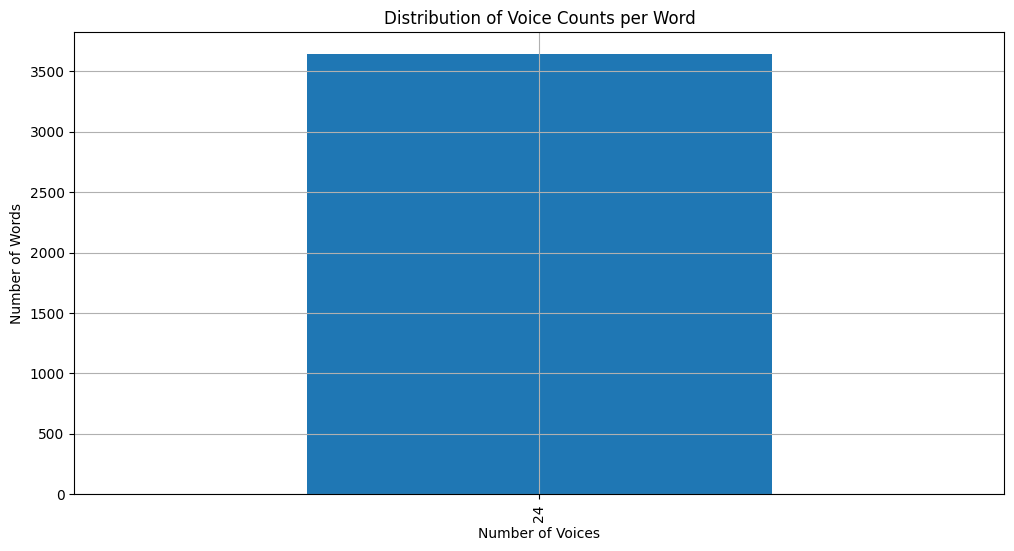

In [23]:
dataset.word_analyzer.plot_voice_distribution()

In [25]:
duration_stats = dataset.stats.analyze_durations()
duration_stats

Analyzing durations: 100%|██████████| 3642/3642 [02:07<00:00, 28.58it/s]


{'avg': 3.142242250423257,
 'max': 8.9836875,
 'min': 1.3166875,
 'above_avg': 38371,
 'below_avg': 49037,
 'total_files': 87408}

Sampling durations: 100%|██████████| 500/500 [00:02<00:00, 189.72it/s]


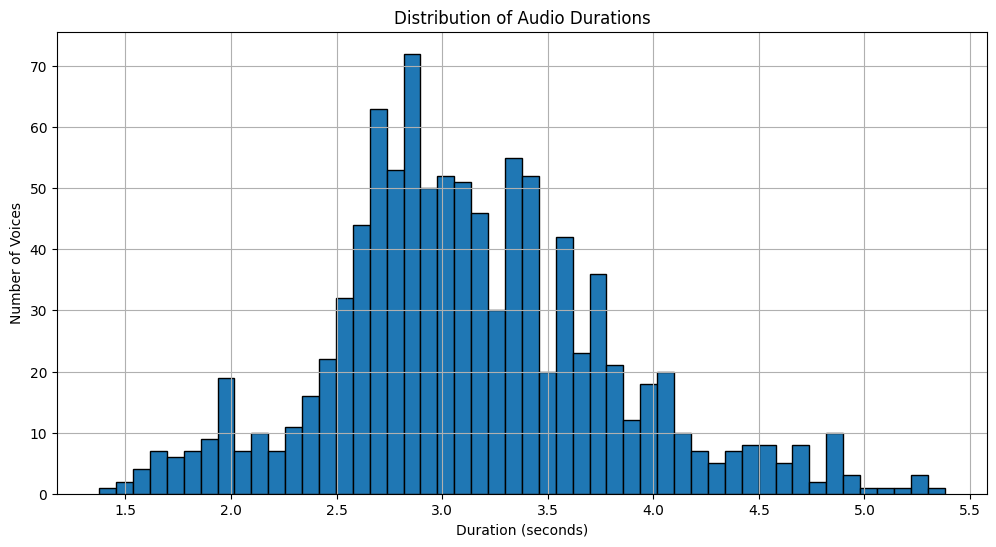

In [71]:
dataset.stats.plot_duration_distribution()

**`DONE`**\
Writing Preprocessing Functions - (Assignee: Mohammad)\
Sprint Goal: [Writing important functions for speech preprocessing]\
Deadline: 02/May

In [26]:
# Writing preprocessing function for audio


# === Parameters ===
TARGET_SAMPLE_RATE = 16000
TARGET_DURATION = duration_stats["avg"]
TARGET_LENGTH = int(TARGET_SAMPLE_RATE * TARGET_DURATION)
TARGET_DB = -20
TRIM_TOP_DB = 30

# === Helper Functions ===

def trim_silence(y, top_db=TRIM_TOP_DB):
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    return yt

def peak_normalize(y):
    peak = np.max(np.abs(y))
    return y / peak if peak > 0 else y

def loudness_normalize(y, target_db=TARGET_DB):
    rms = np.sqrt(np.mean(y ** 2))
    target_rms = 10 ** (target_db / 20)
    return y * (target_rms / (rms + 1e-6))

def load_resample_audio(filepath:str, sample_rate:int=TARGET_SAMPLE_RATE):
    y, sr = librosa.load(filepath, sr=sample_rate, mono=True)
    return y, sr

def padding_or_trimming(signal:list, target_length:int=TARGET_LENGTH):
    if len(signal) > target_length:
        return signal[:target_length]

    elif len(signal) < target_length:
        padding_amount = target_length - len(signal)
        return np.pad(signal, (0, padding_amount), mode='constant')

    else:
        return signal.copy()


def preprocess_audio_file(input_path: str, save_wav: bool = False, save_path: Optional[str] = None) -> Optional[np.ndarray]:
    try:
        y, sr = load_resample_audio(input_path)

        y = nr.reduce_noise(y=y, sr=sr)
        y = trim_silence(y)
        y = peak_normalize(y)
        y = loudness_normalize(y)
        y = padding_or_trimming(y)

        if np.any(np.isnan(y)):
            raise ValueError("NaN values detected after preprocessing.")

        if save_wav and save_path:
            sf.write(save_path, y, sr)

        return y

    except Exception as e:
        print(f"Failed to process {input_path}: {e}")

# *4. Feature Extraction*

**`DONE`**\
Writing Feature Extraction Functions - (Assignee: Shakiba)\
Sprint Goal: [Writing function for extracting features from voices for different model training]\
Deadline: 02/May

***Feature Extraction With MFCC,MEL,...***

In [27]:
# Writing Feature Extraction (without using models)

# ##############################################################
# ___________________________Features___________________________
# ##############################################################
class FeatureExtractor(ABC):
    def extract(self, audio_input: Union[str, np.ndarray], sr: int = 16000) -> np.ndarray:
        if isinstance(audio_input, str):
            y, _ = librosa.load(audio_input, sr=sr)
        elif isinstance(audio_input, np.ndarray):
            y = audio_input
        else:
            raise ValueError("Unsupported audio input type. Must be a file path or numpy array.")
        return self._extract_from_array(y, sr)

    @abstractmethod
    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        pass


class MFCCFeatureExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_mfcc: int = 40):
        self.sr = sr
        self.n_mfcc = n_mfcc

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)
        return mfcc.T


class MelSpectrogramExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_mels: int = 80):
        self.sr = sr
        self.n_mels = n_mels

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=self.n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db.T


class SpectralContrastExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_fft: int = 2048, hop_length: int = 512):
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        contrast = librosa.feature.spectral_contrast(
            y=y, sr=sr, n_fft=self.n_fft, hop_length=self.hop_length
        )
        return contrast.T


class ZeroCrossingRateExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, frame_length: int = 2048, hop_length: int = 512):
        self.sr = sr
        self.frame_length = frame_length
        self.hop_length = hop_length

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        zcr = librosa.feature.zero_crossing_rate(
            y, frame_length=self.frame_length, hop_length=self.hop_length
        )
        return zcr.T

# ##############################################################
# _________________________Handling_____________________________
# ##############################################################

class FeatureSaver:
    def __init__(self, base_output_dir: str):
        self.base_output_dir = base_output_dir

    def save(self, features: np.ndarray, rel_path: str):
        full_path = os.path.join(self.base_output_dir, rel_path)
        os.makedirs(os.path.dirname(full_path), exist_ok=True)
        np.save(full_path, features)


class HandFeatureExtraction:
    def __init__(self, dataset: 'PazhvakDataset', extractor: FeatureExtractor, feature_name: str):
        self.dataset = dataset
        self.extractor = extractor
        self.feature_name = feature_name
        self.output_dir = os.path.join(dataset.dataset_path, "features", self.feature_name)
        self.saver = FeatureSaver(self.output_dir)

    def feature_extraction(self):
      for range_folder in os.listdir(self.dataset.dataset_path):
        range_path = os.path.join(self.dataset.dataset_path, range_folder)
        if not os.path.isdir(range_path):
          print("Not founding root folder")
          continue

        for speaker_id in os.listdir(range_path):
          speaker_path = os.path.join(range_path, speaker_id)
          if not os.path.isdir(speaker_path):
            print("Not founding sub-folders")
            continue

          for audio_file in os.listdir(speaker_path):
              if not audio_file.lower().endswith(('.wav', '.mp3', '.flac')):
                print("Not founding the right format!")
                continue

              audio_path = os.path.join(speaker_path, audio_file)
              try:
                  features = self.extractor.extract(audio_path)
                  feature_sub_dir = os.path.join(self.output_dir, range_folder, speaker_id)
                  os.makedirs(feature_sub_dir, exist_ok=True)
                  filename = os.path.splitext(audio_file)[0] + ".npy"
                  self.saver.save(features, os.path.join(range_folder, speaker_id, filename))

              except Exception as e:
                  print(f"[✘] Failed to extract {audio_file}: {e}")


In [76]:
# MFCC
# extractor = MFCCFeatureExtractor()
# feature_pipeline = HandFeatureExtraction(dataset, extractor, feature_name="mfcc")
# feature_pipeline.feature_extraction()

# Mel Spectrogram
mel_extractor = MelSpectrogramExtractor()
mel_pipeline = HandFeatureExtraction(dataset, mel_extractor, feature_name="mel")
mel_pipeline.feature_extraction()


KeyboardInterrupt: 

***Feature Extraction With Trained Model (Persian ASR Model or Wav2Vec...)***

In [ ]:
class Wav2VecFeatureExtractor(FeatureExtractor):
    def __init__(self, model_name="m3hrdadfi/wav2vec2-large-xlsr-persian", device="cuda" if torch.cuda.is_available() else "cpu"):
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2Model.from_pretrained(model_name).to(device)
        self.device = device
        self.sr = 16000

    def extract(self, audio_path: str) -> np.ndarray:
        y, _ = librosa.load(audio_path, sr=self.sr)

        inputs = self.processor(y, sampling_rate=self.sr, return_tensors="pt", padding=True)
        input_values = inputs.input_values.to(self.device)

        with torch.no_grad():
            outputs = self.model(input_values)
            hidden_states = outputs.last_hidden_state.squeeze(0)  # (seq_len, hidden_dim)

        return hidden_states.cpu().numpy()


class Wav2VecBaseTorchaudioFeatureExtractor(FeatureExtractor):
    def __init__(self):
        self.bundle = torchaudio.pipelines.WAV2VEC2_BASE
        self.model = self.bundle.get_model()
        self.sample_rate = self.bundle.sample_rate

    def extract(self, audio_path: str) -> np.ndarray:
        waveform, sr = torchaudio.load(audio_path)

        if sr != self.sample_rate:
            resampler = T.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform = resampler(waveform)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)  # convert to mono

        with torch.inference_mode():
            features = self.model.extract_features(waveform)[0][0]  # first layer

        return features.numpy()


In [ ]:
# Choose extractor: e.g., Wav2Vec2
wav2vec_extractor = Wav2VecFeatureExtractor(model_name="m3hrdadfi/wav2vec2-large-xlsr-persian")

# Use the same HandFeatureExtraction class
extractor = HandFeatureExtraction(dataset, wav2vec_extractor, feature_name="wav2vec")

# Run extraction
extractor.feature_extraction()


# Create extractor for torchaudio base model
wav2vec_torch_extractor = Wav2VecBaseTorchaudioFeatureExtractor()

# Create feature extraction pipeline
hand_extractor = HandFeatureExtraction(dataset, wav2vec_torch_extractor, feature_name="wav2vec_base_torchaudio")

# Run extraction
hand_extractor.feature_extraction()



Running the Preprocessing and Feature Engineering Pipeline for dataset

In [28]:
class AudioProcessingPipeline:
    def __init__(self,
                 dataset: PazhvakDataset,
                 feature_extractor: FeatureExtractor,
                 save_wav_after_preprocess: bool = False,
                 save_dir_name: str = "processed",
                 feature_name: str = "features"):

        self.dataset = dataset
        self.dataset_root = dataset.dataset_path
        self.feature_extractor = feature_extractor
        self.save_wav = save_wav_after_preprocess
        self.wav_output_root = os.path.join(self.dataset_root, save_dir_name)
        self.feature_output_root = os.path.join(self.dataset_root, feature_name)
        self.saver = FeatureSaver(self.feature_output_root)

    def run(self):
        for root, _, files in os.walk(self.dataset_root):
            for file in files:
                if not file.lower().endswith((".wav", ".flac", ".mp3")):
                    continue

                file_path = os.path.join(root, file)
                rel_path = os.path.relpath(file_path, self.dataset_root)
                new_wav_path = os.path.join(self.wav_output_root, rel_path)

                # Preprocess
                preprocessed_audio = preprocess_audio_file(
                    input_path=file_path,
                    save_wav=self.save_wav,
                    save_path=new_wav_path if self.save_wav else None
                )

                if preprocessed_audio is None:
                    print(f"[✘] audio file is None {preprocessed_audio}")
                    continue

                # Feature Extraction
                try:
                    features = self.feature_extractor.extract(preprocessed_audio, sr=TARGET_SAMPLE_RATE)
                    feature_filename = os.path.splitext(rel_path)[0] + ".npy"
                    self.saver.save(features, feature_filename)
                except Exception as e:
                    print(f"[✘] Failed to extract features from {file_path}: {e}")
        shutil.copy("/content/balanced_pazhvak/P1993818924117826_1247741184149835.xlsx", "/content/balanced_pazhvak/features/P1993818924117826_1247741184149835.xlsx")

In [29]:
mfcc_extractor = MFCCFeatureExtractor()
mel_extractor = MelSpectrogramExtractor()
audio_pipeline = AudioProcessingPipeline(dataset, mel_extractor)
audio_pipeline.run()

In [33]:
# Saving the features config
feature_types = "mfcc"
output_zip = f"/content/{feature_types}_feature_dataset.zip"

# Zip the features folder and labels.xlsx
shutil.make_archive(base_name=output_zip.replace(".zip", ""),
                    format='zip',
                    root_dir=dataset.dataset_path,
                    base_dir='features')


labels_path = f"{dataset.dataset_path}/P1993818924117826_1247741184149835.xlsx"

with zipfile.ZipFile(output_zip, 'a') as zipf:
    zipf.write(labels_path, arcname="P1993818924117826_1247741184149835.xlsx")

In [34]:
# for saving in google drive
from google.colab import drive
drive.mount('/content/drive')

# Move zip to Google Drive
shutil.move(output_zip, "/content/drive/MyDrive/feature_dataset.zip")


Mounted at /content/drive


'/content/drive/MyDrive/feature_dataset.zip'

In [ ]:
# for kaggle
from google.colab import files
files.upload()

dataset_dir = "/content/kaggle/feature_dataset"
os.makedirs(dataset_dir, exist_ok=True)

shutil.move(f"/content/{feature_types}_feature_dataset.zip", dataset_dir)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

metadata = {
    "title": "Feature Dataset for Audio Processing",
    "id": "sepehrsimkhah/feature-dataset-audio",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(os.path.join(dataset_dir, "dataset-metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)


!kaggle datasets create -p /content/kaggle/feature_dataset

# *5. Model Training*

**For Model Training, we have these strategies:**


1.   Training our dataset with custom model which are CNN, LSTM, CRNN(combination of cnn and lstm).
2.   Just training the NN classifers with wav2vec features.
3.   Fine Tuning a trained Persian ASR with a little epochs.
4.   Getting ASR Tokenization part and just fine tuned that and add a simple classifers.



**`DONE`**\
Writing CNN models - (Assignee: Shakiba)\
Sprint Goal: [Writing function for creating a CNN model with input layers of dataset features (we use mel-spectrograms for CNN so use this shape: (n_mels, time_steps)) and the output is 4018]\
Deadline: 30/May

In [12]:
# Write the CNN light model function
def build_cnn_light(input_shape, num_classes:int=4018):
    cnn_model = keras.models.Sequential([
        keras.layers.Conv2D(16, (3,3), input_shape=input_shape, padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),

        keras.layers.Conv2D(32, (3,3), padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(128, (3,3), activation="relu", padding="same", strides=(1,1)),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(num_classes, activation="softmax")
    ])

    return cnn_model

In [13]:
# Write the CNN medium model function
def build_cnn_medium(input_shape, num_classes:int=4018):
    cnn_model = keras.models.Sequential([
        keras.layers.Conv2D(64, (3,3), input_shape=input_shape, padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),

        keras.layers.Conv2D(64, (3,3), padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(128, (3,3), activation="relu", padding="same", strides=(1,1)),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),

        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(num_classes, activation="softmax")
    ])

    return cnn_model

In [14]:
# Write the CNN heavy model function
def build_cnn_heavy(input_shape, num_classes:int=4018):
    cnn_model = keras.models.Sequential([
        keras.layers.Conv2D(128, (3,3), input_shape=input_shape, padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),

        keras.layers.Conv2D(128, (3,3), padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(256, (3,3), padding="same", strides=(1,1)),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Conv2D(512, (3,3), activation="relu", padding="same", strides=(1,1)),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),

        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(num_classes, activation="softmax")
    ])

    return cnn_model

**`DONE`**\
Writing LSTM Models - (Assignee: Shakiba)\
Sprint Goal: [Writing function for creating a LSTM model with input layers of dataset features(we use mfcc for LSTM so use this shape: (time_steps, n_mfcc)) and the output is 4018]\
Deadline: 30/May

In [15]:
# Write the LSTM light model function
def build_lstm_light(input_shape, num_classes:int=4018):

    lstm_model = keras.models.Sequential([
        keras.layers.LSTM(128, input_shape=input_shape, return_sequences=True),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.LSTM(64, return_sequences=True),

        keras.layers.TimeDistributed(keras.layers.Dense(64, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(32, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(16, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(8, activation="relu")),

        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ])
    return lstm_model

In [16]:
# Write the LSTM medium model function
def build_lstm_medium(input_shape, num_classes:int=4018):

    lstm_model = keras.models.Sequential([
        keras.layers.LSTM(256, input_shape=input_shape, return_sequences=True),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.LSTM(128, return_sequences=True),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.LSTM(64, return_sequences=True),

        keras.layers.TimeDistributed(keras.layers.Dense(64, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(32, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(16, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(8, activation="relu")),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ])
    return lstm_model

In [17]:
# Write the LSTM heavy model function
def build_lstm_heavy(input_shape, num_classes:int=4018):

    lstm_model = keras.models.Sequential([
        keras.layers.LSTM(512, input_shape=input_shape, return_sequences=True),
        keras.layers.LayerNormalization(),

        keras.layers.LSTM(256, return_sequences=True),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.LSTM(256, return_sequences=True),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.LSTM(128, return_sequences=True),

        keras.layers.TimeDistributed(keras.layers.Dense(128, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(64, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(32, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(16, activation="relu")),
        keras.layers.TimeDistributed(keras.layers.Dense(8, activation="relu")),

        keras.layers.Flatten(),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ])
    return lstm_model

**`DONE`**\
Writing CRNN Models - (Assignee: Sepehr)\
Sprint Goal: [Writing function for creating a CRNN model or import that model with for training]\
Deadline: 30/May

In [18]:
# Write the CRNN model function
def build_crnn(input_shape, num_classes:int = 4018):
  """
    input_shape: (time_steps, freq_bins, channels)
  """
  crnn_model = keras.models.Sequential()

  crnn_model.add(keras.layers.InputLayer(input_shape=input_shape))
  crnn_model.add(keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
  crnn_model.add(keras.layers.BatchNormalization())
  crnn_model.add(keras.layers.MaxPooling2D((2,2)))
  crnn_model.add(keras.layers.Dropout(0.2))

  crnn_model.add(keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
  crnn_model.add(keras.layers.BatchNormalization())
  crnn_model.add(keras.layers.MaxPooling2D((2,2)))
  crnn_model.add(keras.layers.Dropout(0.3))

  crnn_model.add(keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
  crnn_model.add(keras.layers.BatchNormalization())
  crnn_model.add(keras.layers.MaxPooling2D((2,2)))
  crnn_model.add(keras.layers.Dropout(0.5))

  time_steps = input_shape[0] // 8
  features = (input_shape[1] // 8) * 256

  crnn_model.add(keras.layers.Reshape((time_steps, features)))

  crnn_model.add(keras.layers.Bidirectional(keras.layers.LSTM(128, return_sequences=True)))
  crnn_model.add(keras.layers.LayerNormalization())
  crnn_model.add(keras.layers.Dropout(0.3))

  crnn_model.add(keras.layers.Bidirectional(keras.layers.LSTM(64)))
  crnn_model.add(keras.layers.LayerNormalization())
  crnn_model.add(keras.layers.Dropout(0.3))

  crnn_model.add(keras.layers.Bidirectional(keras.layers.LSTM(32)))
  crnn_model.add(keras.layers.LayerNormalization())
  crnn_model.add(keras.layers.Dropout(0.3))



  crnn_model.add(keras.layers.Dense(128, activation='relu'))
  crnn_model.add(keras.layers.Dropout(0.5))

  crnn_model.add(keras.layers.Dense(256, activation='relu'))
  crnn_model.add(keras.layers.Dropout(0.5))

  crnn_model.add(keras.layers.Dense(num_classes, activation='softmax'))
  return crnn_model


Fine Tuning An Persian ASR Model - (Assignee: Sepehr)\
Sprint Goal: [Writing function for fine tuning a ASR model]\
Deadline: 30/May

In [ ]:
# TODO: Write the fine tuning function here

Trained Persian ASR And Classifer Model - (Assignee: Sepehr)\
Sprint Goal: [Writing function for creating a pipeline that a part is Trained Persian ASR tokenizer layer and the other part is classifier model with fully connected network]\
Deadline: 30/May

In [ ]:
# TODO: Write the pipeline function here

Training Part

In [19]:
# loading the data by getting indices and return the array of datas for each (train, test, valid)

def get_data(dataset: PazhvakDataset, split: str = "train"):
    """
    Load precomputed .npy features and labels from dataset based on split.

    Args:
        dataset (PazhvakDataset): The dataset instance.
        split (str): One of 'train', 'val', or 'test'.

    Returns:
        X (np.ndarray): Array of features.
        y (np.ndarray): Array of class labels (words).
    """
    if split == "train":
        indices = dataset.train_indices
    elif split == "val":
        indices = dataset.val_indices
    elif split == "test":
        indices = dataset.test_indices
    else:
        raise ValueError("Invalid split name. Choose from: 'train', 'val', 'test'.")

    X = []
    y = []

    for idx in indices:
        try:
            sample_path = dataset.metadata.iloc[idx]['Folder Number']
            label = dataset.metadata.iloc[idx]['Persian Word']
            word_range_folder = dataset._find_word_range(int(sample_path))

            # Load .npy feature
            folder_path = os.path.join(dataset.dataset_path, word_range_folder,str(sample_path))
            for file_path in os.listdir(folder_path):
              feature_path = os.path.join(folder_path, file_path)
              features = np.load(feature_path)

              X.append(features)
              y.append(label)

        except Exception as e:
            print(f"Error loading index {idx}: {e}")

    return np.array(X), np.array(y)


In [20]:
# Splitting dataset
dataset = PazhvakDataset(dataset_path="/content/balanced_pazhvak/features", metadata_file="P1993818924117826_1247741184149835.xlsx")
dataset.split_dataset(test_size=0.2, val_size=0.1)

X_train, y_train = get_data(dataset, split="train")
X_val, y_val = get_data(dataset, split="val")
X_test, y_test = get_data(dataset, split="test")


In [21]:
# Encoding Dataset
label_encoder = LabelEncoder()
label_encoder.fit(dataset.metadata['Persian Word'])

y_train = to_categorical(label_encoder.transform(y_train))
y_val = to_categorical(label_encoder.transform(y_val))
y_test = to_categorical(label_encoder.transform(y_test))

In [22]:
NUM_CLASSES = len(dataset.metadata)
NUM_CLASSES

3642

In [23]:
X_train[:2], y_train[:2]


(array([[[-4.6397217e+02,  5.1802315e+01,  5.6562180e+01, ...,
          -9.0131474e+00, -2.5538981e+00, -5.7729018e-01],
         [-4.9266754e+02,  5.5081768e+01,  6.1070751e+01, ...,
          -6.9562140e+00, -4.8879588e-01, -2.6762748e+00],
         [-5.3060187e+02,  7.1214081e+01,  6.6156036e+01, ...,
           6.8043816e-01, -8.9656347e-01, -2.5853866e-01],
         ...,
         [-5.8385101e+02,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [-5.8385101e+02,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [-5.8385101e+02,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
 
        [[-5.1241278e+02,  4.8030380e+01,  4.4468239e+01, ...,
          -2.8634408e-01, -1.9722404e-01,  2.5054086e-02],
         [-4.9751962e+02,  6.8163025e+01,  6.1962067e+01, ...,
          -1.1706099e-01,  3.6762145e-01,  7.9936445e-01],
       

In [24]:
X_train.shape, y_train.shape

((61152, 99, 40), (61152, 3641))

In [ ]:
# Activating GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Using CPU.")

In [25]:
# Model Compiler
def compile_model(model):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [26]:
# Callbacks (TensorBoard, EarlyStopping)
def get_callbacks(model_name):
    log_dir = f"logs/{model_name}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)
    earlystop_cb = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint_cb = ModelCheckpoint(f"{model_name}_best.h5", save_best_only=True)
    return [tensorboard_cb, earlystop_cb, checkpoint_cb]


In [27]:
# Training Function
def train_and_evaluate(model_fn, model_name, input_shape, num_classes, epochs=50, batch_size=32):
    model = model_fn(input_shape=input_shape, num_classes=num_classes)
    print(model.summary())
    compile_model(model)
    callbacks = get_callbacks(model_name)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"[{model_name}] Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

    return model, history


In [28]:
# Comparing All Models
input_shape = X_train.shape[1:]  # (timesteps, features)

# Train and evaluate all
models = {
    "lstm_light": build_lstm_light,
    "lstm_medium": build_lstm_medium,
    "lstm_heavy": build_lstm_heavy,
}

results = {}

for name, model_fn in models.items():
    print(f"\n🔧 Training model: {name}")
    model, history = train_and_evaluate(model_fn, name, input_shape, NUM_CLASSES-1, epochs=10)
    results[name] = {
        "model": model,
        "history": history
    }



🔧 Training model: lstm_light


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 99, 128)        │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 99, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 99, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 99, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 99, 64)         │         4,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 99, 32)         │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 99, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 99, 8)          │           136 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 792)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3641)           │       120,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,081 (1.21 MB)

 Trainable params: 316,081 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
 710/1911 ━━━━━━━━━━━━━━━━━━━━ 6:11 309ms/step - accuracy: 5.2041e-04 - loss: 8.1459

KeyboardInterrupt: 

In [ ]:
# Visualize Performance Comparison
def plot_histories(histories):
    plt.figure(figsize=(12, 6))
    for name, data in histories.items():
        plt.plot(data['history'].history['val_accuracy'], label=f"{name} (val)")
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

plot_histories(results)


# *6. Evaluation and Prediction*

Writing Evaluation Metrics - (Assignee: Shakiba)\
Sprint Goal: [Writing function for metrics(Accuracy, Presicion, Recall, F1-Score) and also other metrics if it needed]\
Deadline: 02/June

In [ ]:
# TODO: Write the Evaluation function here

# *7. Deployment*

Writing Gradio Function for better Interfaces - (Assignee: Shakiba)\
Sprint Goal: [Writing function for opening an simple UI/UX with Gradio libraries]\
Deadline: 04/June

In [ ]:
# TODO: Write the UI/UX function for testing with gradio here

# *8. Model no.1*

**`DONE`**\
Testing Trained Model - (Assignee: Sepehr)\
Sprint Goal: [Importing a trained persian model to test dataset how good is it]\
Deadline: 02/May

In [ ]:
# for evaluation in huggingface

class ASREvaluator:
    def __init__(self, dataset, model_name="m3hrdadfi/wav2vec2-large-xlsr-persian"):
        self.dataset = dataset
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)
        self.wer_metric = load("wer")
        self.cer_metric = load("cer")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)

    def _preprocess_audio(self, waveform, sample_rate):
        """Resample and prepare audio for model"""
        self.resampler.orig_freq = sample_rate
        waveform = self.resampler(waveform)
        return waveform.squeeze()

    def _transcribe(self, waveform):
        """Run inference on single audio sample"""
        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(**inputs).logits

        pred_ids = torch.argmax(logits, dim=-1)
        return self.processor.batch_decode(pred_ids)[0]

    def evaluate_split(self, split="test", max_samples=None):
        """
        Evaluate model on a dataset split
        Args:
            split: 'train', 'test', or 'valid'
            max_samples: maximum samples to evaluate (None for all)
        Returns:
            dict: {'wer': float, 'cer': float, 'samples': list}
        """
        if split not in ["train", "test", "valid"]:
            raise ValueError("Split must be train/test/valid")

        indices = getattr(self.dataset, f"{split}_indices")
        if max_samples:
            indices = indices[:max_samples]

        results = {
            'actual': [],
            'predicted': [],
            'wer': [],
            'cer': []
        }

        for idx in tqdm(indices, desc=f"Evaluating {split} set"):
            try:
                audio_data = self.dataset.get_audio_sample(index=idx)
                waveform, sample_rate, actual_word = audio_data[0][:-1]

                waveform = self._preprocess_audio(waveform, sample_rate)
                predicted_text = self._transcribe(waveform)

                wer = self.wer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )
                cer = self.cer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )

                results['actual'].append(actual_word)
                results['predicted'].append(predicted_text)
                results['wer'].append(wer)
                results['cer'].append(cer)

            except Exception as e:
                print(f"Error processing sample {idx}: {str(e)}")
                continue

        avg_wer = sum(results['wer']) / len(results['wer'])
        avg_cer = sum(results['cer']) / len(results['cer'])

        return {
            'wer': avg_wer,
            'cer': avg_cer,
            'samples': list(zip(results['actual'], results['predicted']))
        }

    def evaluate_all(self, max_samples_per_split=100):
        """Evaluate on all splits"""
        return {
            'train': self.evaluate_split('train', max_samples_per_split),
            'valid': self.evaluate_split('valid', max_samples_per_split),
            'test': self.evaluate_split('test', max_samples_per_split)
        }

In [ ]:
# Separately and not using ASREvaluator class
model_name = "m3hrdadfi/wav2vec2-large-xlsr-persian"
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)

audio_file = dataset.get_audio_sample()

waveform, sample_rate, word = audio_file[0][:-1]
resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
waveform = resampler(waveform)

inputs = processor(waveform.squeeze(), sampling_rate=16000, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

print("Actual word:", word)
print("Transcription:", transcription)
ipd.Audio(waveform, rate=sample_rate)


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Actual word: بزکوهی
Transcription: بوز کوهی


In [ ]:
evaluator = ASREvaluator(dataset)

test_results = evaluator.evaluate_split('test', max_samples=50)
print(f"WER: {test_results['wer']:.2%}")
print(f"CER: {test_results['cer']:.2%}")

for i, (actual, predicted) in enumerate(test_results['samples'][:5]):
    print(f"\nSample {i+1}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Evaluating test set: 100%|██████████| 50/50 [02:32<00:00,  3.05s/it]

WER: 44.00%
CER: 12.21%

Sample 1:
Actual: رژه
Predicted: رژه

Sample 2:
Actual: می گرفت
Predicted: می گرفتیم

Sample 3:
Actual: خجالت
Predicted: خجالت

Sample 4:
Actual: می ماندید
Predicted: میماندید

Sample 5:
Actual: هدایت
Predicted: هدایت


In [ ]:
# TODO: Writing the evaluation function for this model

# *9. Model no.2*

**`DONE`**\
Testing Trained Model - (Assignee: Sepehr)\
Sprint Goal: [Importing whisper from openai model to test the ASR]\
Deadline: 09/May

In [ ]:
class WhisperEvaluator:
    def __init__(self, dataset, model_size="base", language="fa"):
        self.dataset = dataset
        self.language = language
        self.model = whisper.load_model(model_size)
        self.wer_metric = load("wer")
        self.cer_metric = load("cer")

    def _save_temp_audio(self, waveform, sample_rate, path="temp.wav"):
        """Save audio waveform to a temporary file in Whisper-compatible format"""
        torchaudio.save(path, waveform.unsqueeze(0), sample_rate=sample_rate)

    def _transcribe(self, path: str):
        """Run Whisper transcription"""
        result = self.model.transcribe(path, language=self.language, fp16=torch.cuda.is_available())
        return result["text"].strip()

    def evaluate_split(self, split="test", max_samples=None):
        indices = getattr(self.dataset, f"{split}_indices")
        if max_samples:
            indices = indices[:max_samples]

        results = {
            'actual': [],
            'predicted': [],
            'wer': [],
            'cer': []
        }

        for idx in tqdm(indices, desc=f"Evaluating Whisper on {split} set"):
            try:
                audio_data = self.dataset.get_audio_sample(index=idx)
                waveform, sample_rate, actual_word = audio_data[0][:-1]

                # Whisper expects 16-bit PCM WAV, save it temporarily
                self._save_temp_audio(torch.tensor(waveform), sample_rate)

                predicted_text = self._transcribe("temp.wav")

                wer = self.wer_metric.compute(predictions=[predicted_text], references=[actual_word])
                cer = self.cer_metric.compute(predictions=[predicted_text], references=[actual_word])

                results['actual'].append(actual_word)
                results['predicted'].append(predicted_text)
                results['wer'].append(wer)
                results['cer'].append(cer)

            except Exception as e:
                print(f"Error processing sample {idx}: {str(e)}")
                continue

        avg_wer = sum(results['wer']) / len(results['wer']) if results['wer'] else 1.0
        avg_cer = sum(results['cer']) / len(results['cer']) if results['cer'] else 1.0

        return {
            'wer': avg_wer,
            'cer': avg_cer,
            'samples': list(zip(results['actual'], results['predicted']))
        }

    def evaluate_all(self, max_samples_per_split=100):
        return {
            'train': self.evaluate_split('train', max_samples_per_split),
            'valid': self.evaluate_split('val', max_samples_per_split),
            'test': self.evaluate_split('test', max_samples_per_split)
        }


In [ ]:
whisper_eval = WhisperEvaluator(dataset, model_size="base", language="fa")
test_results = whisper_eval.evaluate_split(max_samples_per_split=50)

print(f"WER: {test_results['wer']:.2%}")
print(f"CER: {test_results['cer']:.2%}")

for i, (actual, predicted) in enumerate(test_results['samples'][:5]):
    print(f"\nSample {i+1}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")


In [ ]:
# TODO: Writing the evaluation function for this model